# <center>Diagonalization</center>
$
\newcommand{\R}{\mathbb R}
\newcommand{\C}{\mathbb C}
\newcommand{\id}{\mathrm{id}}
\newcommand{\I}{\mathrm{i}}
\newcommand{\E}{\mathrm{e}}
\DeclareMathOperator{\Re}{Re}
\DeclareMathOperator{\Im}{Im}
\DeclareMathOperator{\diag}{diag}
\require{AMScd}
$

In [1]:
pkg load symbolic # Call SymPy for exact value calculation of eigenvalues and eigenvectors

### Definition.
Let $A\in\R^{n\times n}$.
We say that $A$ is _diagonalizable_ if there is a diagonal matrix $D\in\C^{n\times n}$ and an invertible matrix $P\in\C^{n\times n}$ so that 
\begin{equation*}
D=P^{-1}AP,
\end{equation*}
or equivalently, $A=PDP^{-1}$.

### Remark.
* If $D$ and $P$ are real matrices, then we say that $A$ is diagonalizable over $\R$.
* If $D$ and $P$ are complex matrices, then we say that $A$ is diagonalizable over $\C$.


### Example.
The matrix $A=\begin{bmatrix} 7 & 4 \\ 3 & 6\end{bmatrix}\in\R^{2\times 2}$ is diagonalizable over $\R$.

In [2]:
A=[sym(7) sym(4); sym(3) sym(6)];
[P,D]=eig(A)
P^(-1)*A*P # Note: P diagonalizes A; P^(-1)AP=D

OctSymPy v2.6.0: this is free software without warranty, see source.
Initializing communication with SymPy using a popen2() pipe.
Some output from the Python subprocess (pid 25326) might appear next.
Python 2.7.15 (default, Jul 23 2018, 21:31:33) 
[GCC 4.2.1 Compatible Apple LLVM 9.0.0 (clang-900.0.39.2)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
>>> >>> 
OctSymPy: Communication established.  SymPy v1.3.
P = (sym 2×2 matrix)

  ⎡-1  4/3⎤
  ⎢       ⎥
  ⎣1    1 ⎦

D = (sym 2×2 matrix)

  ⎡3  0 ⎤
  ⎢     ⎥
  ⎣0  10⎦

ans = (sym 2×2 matrix)

  ⎡3  0 ⎤
  ⎢     ⎥
  ⎣0  10⎦



## Criterion for diagonalizability

### Theorem.
Let $A\in\R^{n\times n}$.
* If $A$ is diagonalizable, then $A$ has $n$ linearly independent eigenvectors.
* If $A$ has $n$ linearly independent eigenvectors, say $\mathbf p_1,\dots, \mathbf p_n$, with corresponding eigenvalues $\lambda_1,\dots, \lambda_n$ (not necessarily distinct), then $A$ is diagonalizable, and in particular,
\begin{equation}
A=PDP^{-1}
\end{equation}
with
\begin{align}
P &= \left[\begin{array}{c|c|c}\mathbf p_1 & \cdots &\mathbf p_n\end{array}\right],\\
D &= \diag(\lambda_1,\dots,\lambda_n) = \begin{bmatrix} \lambda_1 & & \\ & \ddots & \\ & & \lambda_n\end{bmatrix}.
\end{align}

## Multiplicity of eigenvalues and diagonalization

### Theorem.
Let $A\in\R^{n\times n}$, and let $\lambda$ be an eigenvalue of $A$.
The geometric multiplicity of $\lambda$ is less than or equal to the algebraic multiplicity of $\lambda$.

### Corollary.
If $A$ is diagonalizable over $\R$, then the characteristic polynomial $\det(\lambda I-A)$ splits into $n$ linear factors over $\R$.

### Example.
The matrix $A=\begin{bmatrix} -3 & -5\\ 2 & 3\end{bmatrix}$ is not diagonalizable over $\R$.

In [3]:
A=[-3 -5; 2 3]; A=sym(A);
x=sym('x');
expand(det(x*eye(2)-A))

ans = (sym)

   2    
  x  + 1



### Corollary.
$A$ is diagonalizable if and only if the geometric multiplicity of each eigenvalue is equal to its algebraic multiplicity.

### Example.
The matrix $A=\begin{bmatrix} 1 & 2\\ 0 & 1\end{bmatrix}$ is not diagonalizable.

In [4]:
A=[1 2; 0 1]; A=sym(A);
[P,D]=eig(A)
P^(-1) # Note: P is not invertible; its columns are not independent.

P = (sym 2×2 matrix)

  ⎡1  1⎤
  ⎢    ⎥
  ⎣0  0⎦

D = (sym 2×2 matrix)

  ⎡1  0⎤
  ⎢    ⎥
  ⎣0  1⎦

error: Python exception: ValueError: Matrix det == 0; not invertible.
    occurred at line 2 of the Python code block:
    return x**y
error: called from
    python_cmd at line 179 column 7
    mpower at line 76 column 5


### Example.
Diagonalize the matrix $A=\begin{bmatrix} 1 & 0 & 0 & 0\\ 0 & 1 & 5 & -10\\ 1 & 0 & 2 & 0\\ 1 & 0 & 0 & 3\end{bmatrix}$ if possible.

In [5]:
A=[1 0 0 0; 0 1 5 -10; 1 0 2 0; 1 0 0 3]; A=sym(A);
[P,D]=eig(A)

P = (sym 4×4 matrix)

  ⎡0  -2  0  0 ⎤
  ⎢            ⎥
  ⎢1  0   5  -5⎥
  ⎢            ⎥
  ⎢0  2   1  0 ⎥
  ⎢            ⎥
  ⎣0  1   0  1 ⎦

D = (sym 4×4 matrix)

  ⎡1  0  0  0⎤
  ⎢          ⎥
  ⎢0  1  0  0⎥
  ⎢          ⎥
  ⎢0  0  2  0⎥
  ⎢          ⎥
  ⎣0  0  0  3⎦



## Diagonalization as change of basis to an eigenbasis

* Suppose that $A$ is diagonalizable by $P=\left[\begin{array}{c|c|c}\mathbf p_1 & \cdots &\mathbf p_n\end{array}\right]$ and $D=\diag(\lambda_1,\dots,\lambda_n)$.
* We may view $\mathcal B=\{\mathbf p_1,\dots,\mathbf p_n\}$ as a basis -- an _eigenbasis_ -- for $\C^n$ (or $\R^n$ if all matrices are real).
* Then $P=\left[\begin{array}{c|c|c}\mathbf p_1 & \cdots &\mathbf p_n\end{array}\right]$ is the change-of-basis matrix from $\mathcal B$-coordinates to standard coordinates, and $P^{-1}$ is the change-of-basis matrix from standard coordinates to $\mathcal B$-coordinates. 
* Thus, we can view the diagonal matrix $D$ as representing the same linear transformation as $A$ but in $\mathcal B$-coordinates, where the action is much easier to analyze.

<center>
$\begin{CD}
\C^n  @>A>> \C^n\\
@VP=[\id]_{\mathcal B,\mathcal S}VV  @AAP^{-1}=[\id]_{\mathcal S,\mathcal B}A\\
\C^n  @>>D=[A]_{\mathcal B,\mathcal B}> \C^n
\end{CD}$
</center>

### Example.
Analyze the orbit of the point $\mathbf x^{(0)}=(2,3)$ under the discrete linear dynamical system defined by $A=\begin{bmatrix} 2 & 1\\ 1 & 2\end{bmatrix}$.

In [6]:
A=[2 1; 1 2]; A=sym(A);
[P,D]=eig(A)

P = (sym 2×2 matrix)

  ⎡-1  1⎤
  ⎢     ⎥
  ⎣1   1⎦

D = (sym 2×2 matrix)

  ⎡1  0⎤
  ⎢    ⎥
  ⎣0  3⎦



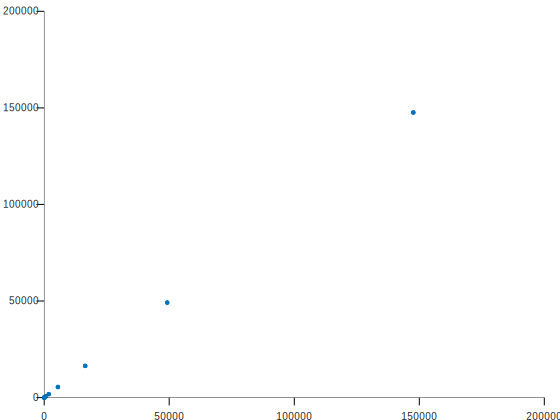

In [7]:
A=[2 1; 1 2];
orbit = [2;3];
K=10;
for k = 1:K
	orbit = [orbit A*orbit(:,k)];
end
scatter(orbit(1,:), orbit(2,:), 'filled')
set(gca,"xaxislocation", "origin","yaxislocation", "origin");

### Example.
Analyze the orbit of the point $\mathbf x^{(0)}=(1,1)$ under the discrete linear dynamical system defined by $A=\begin{bmatrix} \frac{1}{2} & \frac{1}{2}\\ -\frac{1}{2} & \frac{1}{2}\end{bmatrix}$.

In [14]:
A=[1 1; -1 1]; A=sym(A); A=A/2;
[P,D]=eig(A)
k=sym('k');
P^(-1)
P*D^k*P^(-1)

P = (sym 2×2 matrix)

  ⎡ⅈ  -ⅈ⎤
  ⎢     ⎥
  ⎣1  1 ⎦

D = (sym 2×2 matrix)

  ⎡1   ⅈ       ⎤
  ⎢─ - ─    0  ⎥
  ⎢2   2       ⎥
  ⎢            ⎥
  ⎢       1   ⅈ⎥
  ⎢  0    ─ + ─⎥
  ⎣       2   2⎦

ans = (sym 2×2 matrix)

  ⎡-ⅈ      ⎤
  ⎢───  1/2⎥
  ⎢ 2      ⎥
  ⎢        ⎥
  ⎢ ⅈ      ⎥
  ⎢ ─   1/2⎥
  ⎣ 2      ⎦

ans = (sym 2×2 matrix)

  ⎡          k          k              k            k⎤
  ⎢   ⎛1   ⅈ⎞    ⎛1   ⅈ⎞        ⎛1   ⅈ⎞      ⎛1   ⅈ⎞ ⎥
  ⎢   ⎜─ - ─⎟    ⎜─ + ─⎟      ⅈ⋅⎜─ - ─⎟    ⅈ⋅⎜─ + ─⎟ ⎥
  ⎢   ⎝2   2⎠    ⎝2   2⎠        ⎝2   2⎠      ⎝2   2⎠ ⎥
  ⎢   ──────── + ────────     ────────── - ──────────⎥
  ⎢      2          2             2            2     ⎥
  ⎢                                                  ⎥
  ⎢           k            k           k          k  ⎥
  ⎢    ⎛1   ⅈ⎞      ⎛1   ⅈ⎞     ⎛1   ⅈ⎞    ⎛1   ⅈ⎞   ⎥
  ⎢  ⅈ⋅⎜─ - ─⎟    ⅈ⋅⎜─ + ─⎟     ⎜─ - ─⎟    ⎜─ + ─⎟   ⎥
  ⎢    ⎝2   2⎠      ⎝2   2⎠     ⎝2   2⎠    ⎝2   2⎠   ⎥
  ⎢- ────────── + ──────────    ──────── + ────────  ⎥
  ⎣  

* Writing $\lambda_1 = \frac{1-\I}{2}$ and $\lambda_2 = \overline{\lambda_1}$, we have
\begin{equation}
\begin{split}
A^k &= \left(PDP^{-1}\right)^k = PD^kP^{-1}\\
    &= \frac{1}{2}\begin{bmatrix}\I & -\I\\ 1 & 1\end{bmatrix}
       \begin{bmatrix}\lambda_1^k & 0\\ 0 & \lambda_2^k\end{bmatrix}
       \begin{bmatrix}-\I & 1\\ \I & 1\end{bmatrix}\\
    &= \frac{1}{2}\begin{bmatrix}
        \lambda_1^k+\lambda_2^k & \I\left(\lambda_1^k-\lambda_2^k\right)\\
        -\I\left(\lambda_1^k-\lambda_2^k\right) & \lambda_1^k+\lambda_2^k
        \end{bmatrix}\\
    &= \begin{bmatrix}
        \Re(\lambda_1^k) & -\Im(\lambda_1^k)\\
        \Im(\lambda_1^k) & \Re(\lambda_1^k)
        \end{bmatrix}.
\end{split}
\end{equation}
* In polar form, $\lambda_1 = \frac{\E^{-\I\pi/4}}{\sqrt 2}$, and so
\begin{align}
\Re(\lambda_1^k) &= \left(\frac{1}{\sqrt 2}\right)^k\cos(-k\pi/4),\\
\Im(\lambda_1^k) &= \left(\frac{1}{\sqrt 2}\right)^k\sin(-k\pi/4).
\end{align}
* Substituting this above shows that
\begin{equation*}
A^k = \left(\frac{1}{\sqrt 2}\right)^k\begin{bmatrix}
\cos(-k\pi/4) & -\sin(-k\pi/4)\\
\sin(-k\pi/4) & \cos(-k\pi/4)
\end{bmatrix},
\end{equation*}
which is the matrix operator that takes a vector, rescales it by $(1/\sqrt 2)^k$ and rotates it in the plane by $\theta = -k\pi/4$ radians.
* Thus, we expect the points of the orbit to "spiral" toward the origin as $k\rightarrow\infty$.

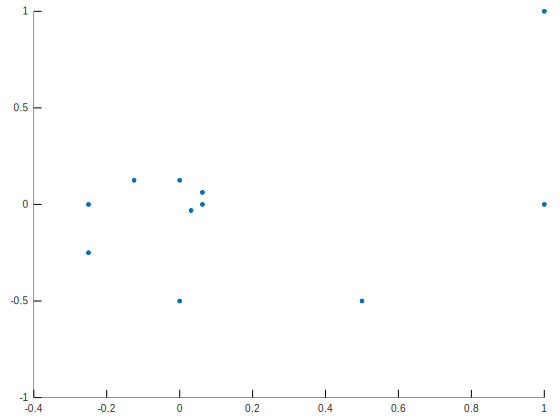

In [9]:
A=[1 1; -1 1]/2;
orbit = [1;1];
K=10;
for k = 1:K
	orbit = [orbit A*orbit(:,k)];
end
scatter(orbit(1,:), orbit(2,:), 'filled')